PHASE 1: DATA UNDERSTANDING

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RAW = "../data/raw"


In [18]:
# load data

credit_applications = pd.read_csv(f"{RAW}/credit_applications.csv")
transactions        = pd.read_csv(f"{RAW}/transaction_data.csv")
customers           = pd.read_csv(f"{RAW}/customer_profiles.csv")
credit_bureau       = pd.read_csv(f"{RAW}/credit_bureau_data.csv")
model_predictions   = pd.read_csv(f"{RAW}/model_predictions.csv") 
 
shapes = {
    "credit_applications": credit_applications.shape,
    "transactions": transactions.shape,
    "customers": customers.shape,
    "credit_bureau": credit_bureau.shape,
    "model_predictions": model_predictions.shape,
}
print(shapes)

{'credit_applications': (100000, 11), 'transactions': (100000, 10), 'customers': (25000, 12), 'credit_bureau': (25000, 8), 'model_predictions': (50000, 11)}


In [19]:
def overview(df, name):
    print(f"\n=== {name} ===")
    print("Shape:", df.shape)
    print("\nDtypes:\n", df.dtypes)
    print("\nMissing values:\n", df.isna().sum().sort_values(ascending=False).head(20))
    display(df.describe(include="all").T)

overview(credit_applications, "credit_applications")
overview(transactions, "transactions")
overview(customers, "customers")
overview(credit_bureau, "credit_bureau")
overview(model_predictions, "model_predictions")



=== credit_applications ===
Shape: (100000, 11)

Dtypes:
 application_id           object
customer_id              object
application_date         object
loan_amount               int64
loan_purpose             object
employment_status        object
annual_income           float64
debt_to_income_ratio    float64
credit_score              int64
application_status       object
default_flag              int64
dtype: object

Missing values:
 application_id          0
customer_id             0
application_date        0
loan_amount             0
loan_purpose            0
employment_status       0
annual_income           0
debt_to_income_ratio    0
credit_score            0
application_status      0
default_flag            0
dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
application_id,100000,100000,APP_0000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,100000,24559,CUST_023466,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
application_date,100000,1095,2022-05-04,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amount,100000.0,NaN,NaN,NaN,93409.77974,97984.843947,1000.0,24955.75,59670.5,128680.75,1246951.0
loan_purpose,100000,7,Personal,14419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_status,100000,7,Full-time,42460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annual_income,100000.0,NaN,NaN,NaN,46379.358926,36321.173666,2.59,16368.01,38850.49,65449.86,315526.34
debt_to_income_ratio,100000.0,NaN,NaN,NaN,0.738666,0.607509,0.203,0.558,0.72,0.893,77.791
credit_score,100000.0,NaN,NaN,NaN,735.08739,86.551664,379.0,675.0,741.0,808.0,850.0
application_status,100000,2,Declined,73717,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== transactions ===
Shape: (100000, 10)

Dtypes:
 transaction_id           object
customer_id              object
transaction_date         object
amount                  float64
merchant_category        object
transaction_type         object
location                 object
device_info              object
fraud_flag                int64
investigation_status     object
dtype: object

Missing values:
 transaction_id          0
customer_id             0
transaction_date        0
amount                  0
merchant_category       0
transaction_type        0
location                0
device_info             0
fraud_flag              0
investigation_status    0
dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,100000,100000,TXN_00000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,100000,24541,CUST_018784,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_date,100000,99940,2024-08-26 00:36:51,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,100000.0,NaN,NaN,NaN,115.260357,250.922703,1.0,16.46,45.37,118.05,14011.65
merchant_category,100000,10,Groceries,20650,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_type,100000,3,Purchase,94025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,100000,10,Glasgow,10366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_info,100000,5,Chip,20268,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fraud_flag,100000.0,NaN,NaN,NaN,0.00139,0.037257,0.0,0.0,0.0,0.0,1.0
investigation_status,100000,4,Not Investigated,99861,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== customers ===
Shape: (25000, 12)

Dtypes:
 customer_id            object
customer_age            int64
annual_income         float64
employment_status      object
account_tenure          int64
product_holdings        int64
relationship_value    float64
risk_segment           object
behavioral_score      float64
credit_score            int64
city                   object
last_activity_date     object
dtype: object

Missing values:
 customer_id           0
customer_age          0
annual_income         0
employment_status     0
account_tenure        0
product_holdings      0
relationship_value    0
risk_segment          0
behavioral_score      0
credit_score          0
city                  0
last_activity_date    0
dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,25000,25000,CUST_000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_age,25000.0,NaN,NaN,NaN,40.93104,26.430429,18.0,19.0,33.0,53.0,247.0
annual_income,25000.0,NaN,NaN,NaN,46329.988618,36325.661235,2.59,16241.7725,38808.21,65311.6975,315526.34
employment_status,25000,7,Full-time,10603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
account_tenure,25000.0,NaN,NaN,NaN,3.4944,2.821582,0.0,1.0,3.0,5.0,24.0
product_holdings,25000.0,NaN,NaN,NaN,2.60944,1.258064,1.0,2.0,2.0,3.0,5.0
relationship_value,25000.0,NaN,NaN,NaN,18300.811888,20249.474776,0.54,4165.175,11110.145,25604.8725,239035.06
risk_segment,25000,4,Prime,11606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
behavioral_score,25000.0,NaN,NaN,NaN,284.662131,158.124258,2.19,162.1875,263.72,386.5325,927.24
credit_score,25000.0,NaN,NaN,NaN,734.8062,86.639867,379.0,675.0,740.0,808.0,850.0



=== credit_bureau ===
Shape: (25000, 8)

Dtypes:
 customer_id               object
credit_score               int64
credit_history_length      int64
number_of_accounts         int64
total_credit_limit         int64
credit_utilization       float64
payment_history          float64
public_records             int64
dtype: object

Missing values:
 customer_id              0
credit_score             0
credit_history_length    0
number_of_accounts       0
total_credit_limit       0
credit_utilization       0
payment_history          0
public_records           0
dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,25000,25000,CUST_000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_score,25000.0,NaN,NaN,NaN,734.8062,86.639867,379.0,675.0,740.0,808.0,850.0
credit_history_length,25000.0,NaN,NaN,NaN,7.16828,9.924168,0.0,0.0,3.0,10.0,100.0
number_of_accounts,25000.0,NaN,NaN,NaN,3.86772,2.182204,0.0,2.0,4.0,5.0,16.0
total_credit_limit,25000.0,NaN,NaN,NaN,16927.35396,20876.745346,500.0,3747.0,9704.5,22039.25,312227.0
credit_utilization,25000.0,NaN,NaN,NaN,0.343184,0.23756,0.0,0.143,0.304,0.513,0.992
payment_history,25000.0,NaN,NaN,NaN,0.904098,0.096134,0.6,0.87,0.94,0.973,1.0
public_records,25000.0,NaN,NaN,NaN,0.02108,0.164185,0.0,0.0,0.0,0.0,3.0



=== model_predictions ===
Shape: (50000, 11)

Dtypes:
 prediction_id              object
model_version              object
customer_id                object
prediction_date            object
prediction_type            object
risk_score                float64
fraud_probability         float64
model_features             object
prediction_explanation     object
business_decision          object
actual_outcome             object
dtype: object

Missing values:
 fraud_probability         25000
risk_score                25000
prediction_id                 0
customer_id                   0
model_version                 0
prediction_type               0
prediction_date               0
model_features                0
prediction_explanation        0
business_decision             0
actual_outcome                0
dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
prediction_id,50000,50000,PRED_0000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_version,50000,4,v1.0,12575,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,50000,21652,CUST_006618,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prediction_date,50000,26091,2024-03-03,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prediction_type,50000,2,Credit Risk,25000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
risk_score,25000.0,NaN,NaN,NaN,402.976336,200.852639,3.45,245.7,390.045,546.8725,987.24
fraud_probability,25000.0,NaN,NaN,NaN,0.101185,0.093959,0.0,0.0315,0.0747,0.1435,0.9843
model_features,50000,49784,"{'amount': 1.0, 'merchant_category': 'Online S...",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prediction_explanation,50000,36786,"Risk driven by credit_score=850, DTI=0.93",65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
business_decision,50000,4,Allow,24977,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Phase 2: Credit Analysis

C:\Users\ooluw\AppData\Local\Temp\ipykernel_4940\2429937447.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('score_range')['default_flag']


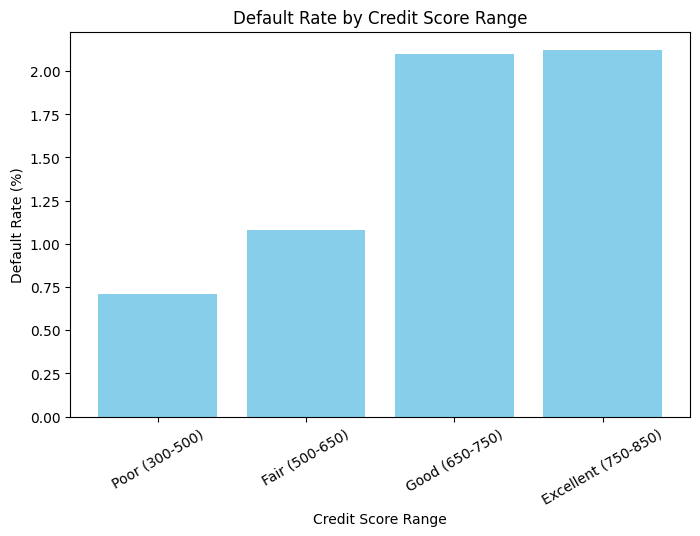

           score_range  default_flag
0       Poor (300-500)      0.007092
1       Fair (500-650)      0.010812
2       Good (650-750)      0.020988
3  Excellent (750-850)      0.021230


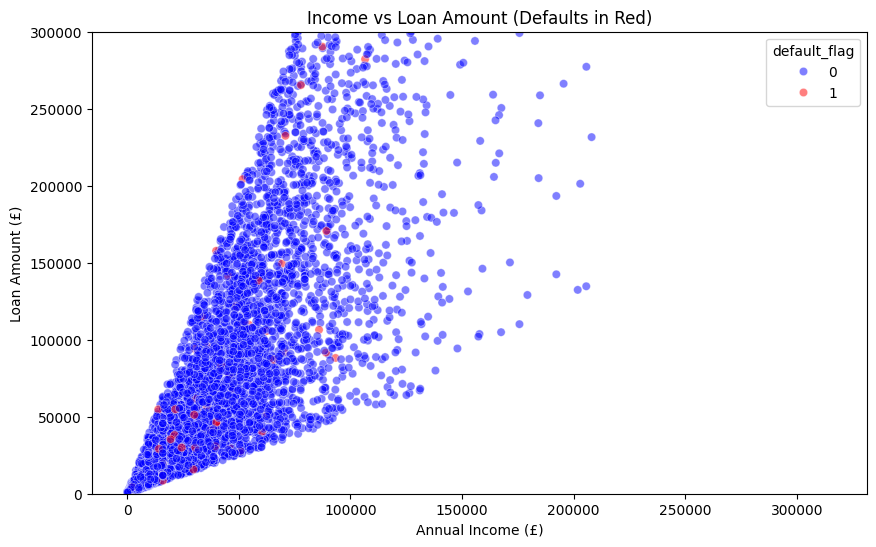

Correlation between Income and Loan Amount: 0.814


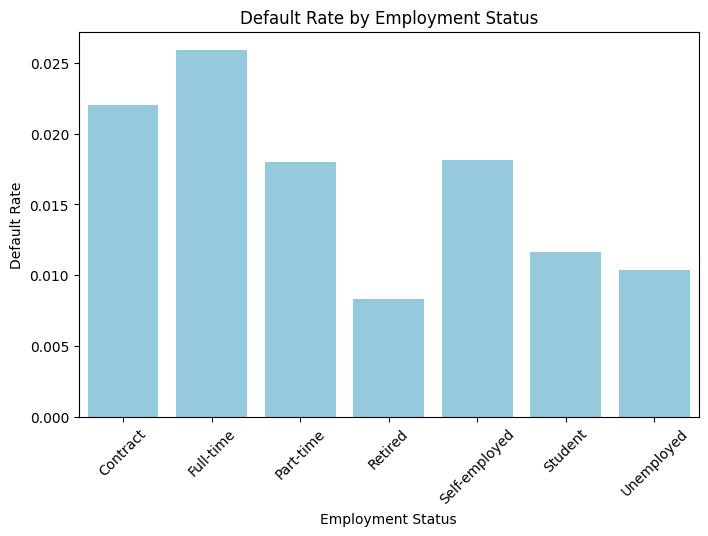


Default Rates by Employment Status:
  employment_status  default_flag
0          Contract      0.021995
1         Full-time      0.025907
2         Part-time      0.018028
3           Retired      0.008349
4     Self-employed      0.018146
5           Student      0.011622
6        Unemployed      0.010350


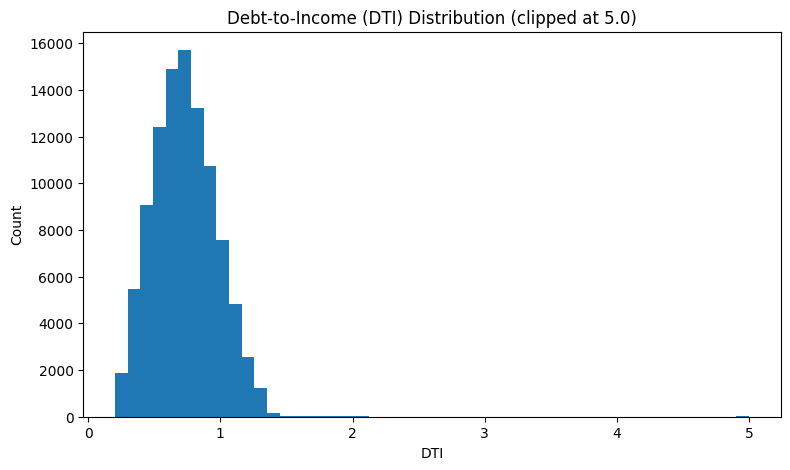

C:\Users\ooluw\AppData\Local\Temp\ipykernel_4940\2429937447.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  apps_dti.groupby('dti_band')


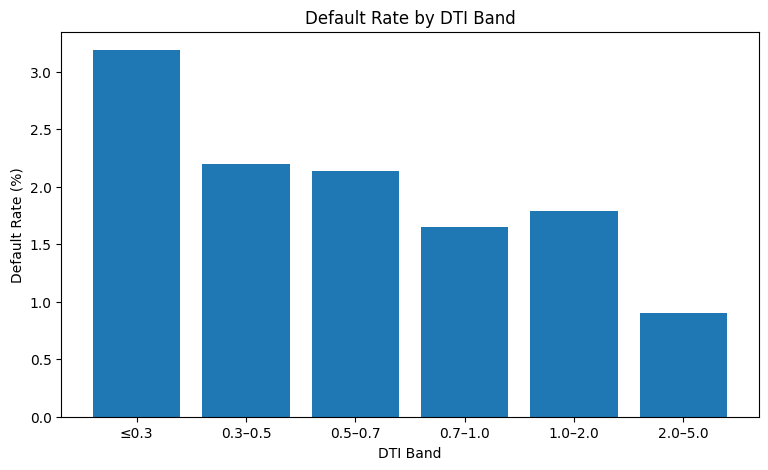


Default rates by DTI band:
  dti_band  default_rate  count
0     ≤0.3      0.031893   1944
1  0.3–0.5      0.022019  15623
2  0.5–0.7      0.021397  29163
3  0.7–1.0      0.016512  39427
4  1.0–2.0      0.017914  13732
5  2.0–5.0      0.009009    111


In [21]:
# 1) Default rate by credit score ranges

# Define bins and labels
bins = [300, 500, 650, 750, 850]
labels = ["Poor (300-500)", "Fair (500-650)", "Good (650-750)", "Excellent (750-850)"]

# Create credit score range column
credit_applications['score_range'] = pd.cut(
    credit_applications['credit_score'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Group by score range to compute default rate
default_rates = (
    credit_applications
    .groupby('score_range')['default_flag']
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(8,5))
plt.bar(default_rates['score_range'], default_rates['default_flag']*100, color="skyblue")
plt.title("Default Rate by Credit Score Range")
plt.ylabel("Default Rate (%)")
plt.xlabel("Credit Score Range")
plt.xticks(rotation=30)
plt.show()

print(default_rates)


# 2) Income vs Loan Amount with default overlay
sample_df = credit_applications.sample(5000, random_state=42)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=sample_df,
    x="annual_income",
    y="loan_amount",
    hue="default_flag",
    palette={0: "blue", 1: "red"},
    alpha=0.5
)

plt.title("Income vs Loan Amount (Defaults in Red)")
plt.xlabel("Annual Income (£)")
plt.ylabel("Loan Amount (£)")
plt.ylim(0, 300000)  # limit for clarity, ignoring extreme outliers
plt.show()

# Correlation check
correlation = credit_applications['annual_income'].corr(credit_applications['loan_amount'])
print("Correlation between Income and Loan Amount:", round(correlation, 3))


# 3) Employment Status vs Default Rate
emp_default = (
    credit_applications
    .groupby('employment_status')['default_flag']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(data=emp_default, x='employment_status', y='default_flag', color="skyblue")
plt.title("Default Rate by Employment Status")
plt.ylabel("Default Rate")
plt.xlabel("Employment Status")
plt.xticks(rotation=45)
plt.show()

print("\nDefault Rates by Employment Status:")
print(emp_default)

# 4) Debt-to-Income (DTI) Distribution
apps_dti = credit_applications.copy()
apps_dti['dti_clip'] = apps_dti['debt_to_income_ratio'].clip(upper=5.0)

plt.figure(figsize=(9,5))
plt.hist(apps_dti['dti_clip'], bins=50)
plt.title('Debt-to-Income (DTI) Distribution (clipped at 5.0)')
plt.xlabel('DTI')
plt.ylabel('Count')
plt.show()


# 5) Default Rate by DTI Band
bins = [0, 0.3, 0.5, 0.7, 1.0, 2.0, 5.0]
labels = ['≤0.3', '0.3–0.5', '0.5–0.7', '0.7–1.0', '1.0–2.0', '2.0–5.0']
apps_dti['dti_band'] = pd.cut(apps_dti['dti_clip'], bins=bins, labels=labels,
                              include_lowest=True, right=True)

band_summary = (
    apps_dti.groupby('dti_band')
            .agg(default_rate=('default_flag','mean'),
                 count=('default_flag','size'))
            .reset_index()
)

plt.figure(figsize=(9,5))
plt.bar(band_summary['dti_band'].astype(str), band_summary['default_rate']*100)
plt.title('Default Rate by DTI Band')
plt.xlabel('DTI Band')
plt.ylabel('Default Rate (%)')
plt.show()

print("\nDefault rates by DTI band:")
print(band_summary)

Phase 3: Fraud Analysis

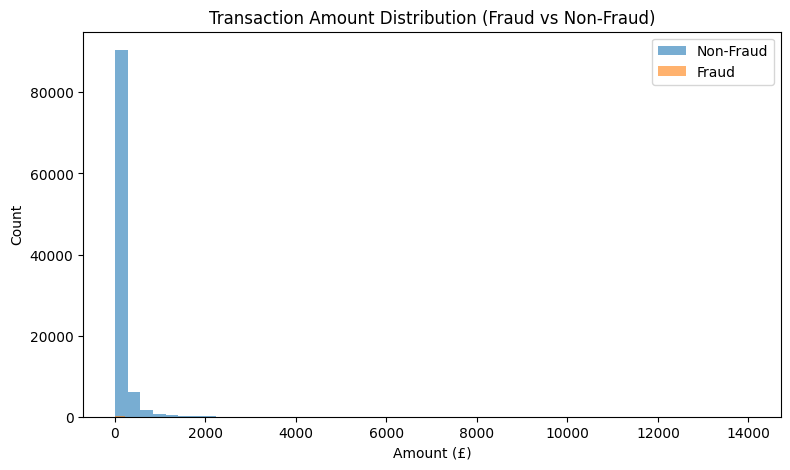

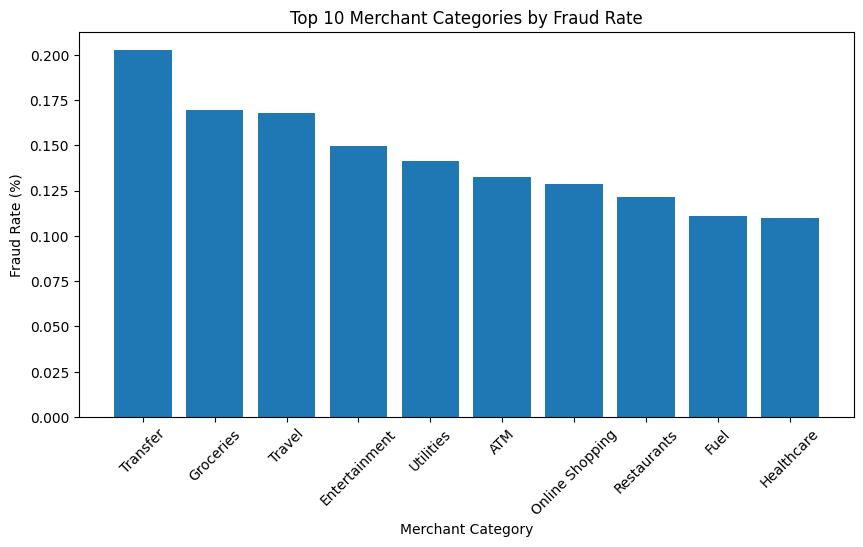

Top Merchant Categories by Fraud Rate:
  merchant_category      mean  count
7          Transfer  0.002025   2963
3         Groceries  0.001695  20650
8            Travel  0.001677   2981
1     Entertainment  0.001498  10678
9         Utilities  0.001411   6377
0               ATM  0.001328   3012
5   Online Shopping  0.001287  17097
6       Restaurants  0.001217  17262
2              Fuel  0.001110  12612
4        Healthcare  0.001099   6368


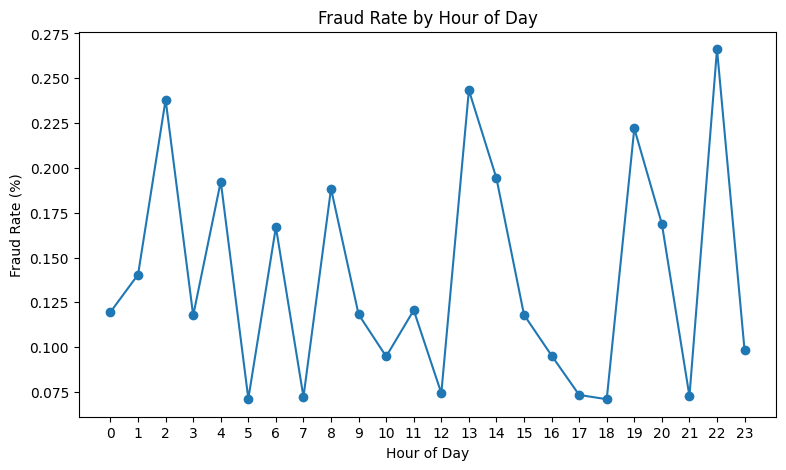

Fraud Rates by Hour of Day:
    hour  fraud_flag
0      0    0.001196
1      1    0.001405
2      2    0.002381
3      3    0.001177
4      4    0.001924
5      5    0.000712
6      6    0.001670
7      7    0.000722
8      8    0.001884
9      9    0.001183
10    10    0.000948
11    11    0.001206
12    12    0.000743
13    13    0.002434
14    14    0.001942
15    15    0.001180
16    16    0.000953
17    17    0.000733
18    18    0.000710
19    19    0.002220
20    20    0.001688
21    21    0.000727
22    22    0.002662
23    23    0.000982


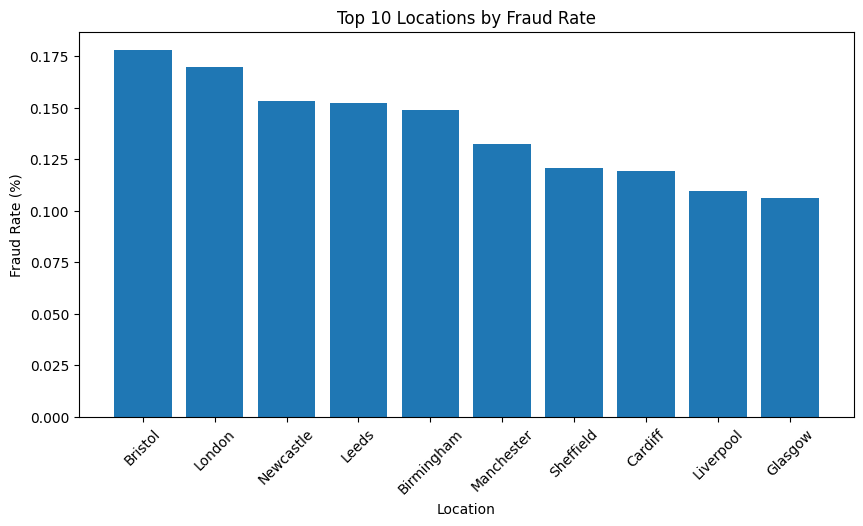

Top Locations by Fraud Rate:
     location      mean  count
1     Bristol  0.001780  10113
6      London  0.001698  10013
8   Newcastle  0.001533   9784
4       Leeds  0.001526   9832
0  Birmingham  0.001490  10064
7  Manchester  0.001326   9805
9   Sheffield  0.001209   9926
2     Cardiff  0.001194  10054
5   Liverpool  0.001095  10043
3     Glasgow  0.001061  10366


In [22]:
# Phase 3: Fraud Analysis

import pandas as pd
import matplotlib.pyplot as plt

# Work on a copy
tx = transactions.copy()

# 1) Transaction Amount Distribution (fraud vs non-fraud)
plt.figure(figsize=(9,5))
plt.hist(tx[tx['fraud_flag']==0]['amount'], bins=50, alpha=0.6, label="Non-Fraud")
plt.hist(tx[tx['fraud_flag']==1]['amount'], bins=50, alpha=0.6, label="Fraud")
plt.title("Transaction Amount Distribution (Fraud vs Non-Fraud)")
plt.xlabel("Amount (£)")
plt.ylabel("Count")
plt.legend()
plt.show()


# 2) Fraud Rate by Merchant Category
fraud_by_cat = (
    tx.groupby('merchant_category')['fraud_flag']
      .agg(['mean','count'])
      .reset_index()
      .sort_values('mean', ascending=False)
)

top_cats = fraud_by_cat.head(10)

plt.figure(figsize=(10,5))
plt.bar(top_cats['merchant_category'], top_cats['mean']*100)
plt.title("Top 10 Merchant Categories by Fraud Rate")
plt.xlabel("Merchant Category")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.show()

print("Top Merchant Categories by Fraud Rate:")
print(top_cats)


# 3) Fraud by Hour of Day
tx['hour'] = pd.to_datetime(tx['transaction_date']).dt.hour

fraud_by_hour = (
    tx.groupby('hour')['fraud_flag']
      .mean()
      .reset_index()
)

plt.figure(figsize=(9,5))
plt.plot(fraud_by_hour['hour'], fraud_by_hour['fraud_flag']*100, marker='o')
plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(0,24))
plt.show()

print("Fraud Rates by Hour of Day:")
print(fraud_by_hour)


# 4) Fraud Rate by Location
fraud_by_location = (
    tx.groupby('location')['fraud_flag']
      .agg(['mean','count'])
      .reset_index()
      .sort_values('mean', ascending=False)
)

top_locations = fraud_by_location.head(10)

plt.figure(figsize=(10,5))
plt.bar(top_locations['location'], top_locations['mean']*100)
plt.title("Top 10 Locations by Fraud Rate")
plt.xlabel("Location")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.show()

print("Top Locations by Fraud Rate:")
print(top_locations)


### ANALYSIS

Amounts: Fraudulent transactions cluster more in the low-to-mid ranges (< £5k) → consistent with “test transactions.”

Merchant Categories: Higher fraud rates in Transfers, Travel, Groceries → these need tighter monitoring rules.

Hour of Day: Fraud spikes during late-night/early-morning hours, when genuine activity is lower.

Locations: Top cities (London, Bristol, Birmingham, etc.) show higher fraud exposure due to volume, but also elevated risk → good for geo-based risk scoring.

Phase 4: Business Insights